# Tuần 4 - Strong Fusion: YOLO/SAHI Crop + DINOv2 + TF-IDF + pHash + Reranking

Notebook này chọn lọc các phần mạnh và hợp dataset Shopee nhất:

```text
Ảnh gốc
→ YOLO/SAHI detect vùng sản phẩm chính
→ Crop vùng sản phẩm
→ DINOv2/ResNet trích xuất feature ảnh gốc
→ DINOv2/ResNet trích xuất feature ảnh crop
→ TF-IDF trích xuất feature title
→ pHash boost ảnh gần trùng
→ Candidate union + reranking
→ Precision@K, Recall@K, mAP@5
```

Không dùng MobileNet/EfficientNet classifier 11k `label_group`, vì dữ liệu Shopee dạng long-tail, nhiều nhóm chỉ có 2-3 ảnh. Ép classification kiểu đó dễ tụt metric và tốn thời gian vô ích.

## CELL 1 - Cài thư viện nếu thiếu

In [14]:
# Nếu chạy Colab/máy mới mà thiếu thư viện, mở comment các dòng dưới.
# !pip install -q faiss-cpu ultralytics sahi opencv-python

print('Nếu lỗi thiếu package, hãy mở comment dòng pip install phía trên rồi chạy lại cell này.')

Nếu lỗi thiếu package, hãy mở comment dòng pip install phía trên rồi chạy lại cell này.


## CELL 2 - Import thư viện và seed

In [15]:
import os
import re
import time
import json
import math
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps, UnidentifiedImageError

try:
    import faiss
except Exception as e:
    raise ImportError('Thiếu faiss. Chạy: pip install faiss-cpu') from e

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as sk_normalize

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('FAISS  :', faiss.__version__)
print('Device :', DEVICE)

PyTorch: 2.12.0+cu126
FAISS  : 1.14.2
Device : cuda


## CELL 3 - Cấu hình đường dẫn và tham số

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ SỬA DATA_DIR CHO ĐÚNG MÁY ĐANG CHẠY                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
DATA_DIR = r'E:\study\DoAnPython\project\data\raw'

CSV_PATH  = os.path.join(DATA_DIR, 'train.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'train_images')

PROCESSED = '../data/processed/'
RESULTS   = '../results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

# Test nhanh thì để 100-500 groups. Chạy báo cáo thì để None.
SAMPLE_GROUPS = None       # None = full dataset; ví dụ 300 = lấy 300 label_group
MAX_PER_GROUP = None       # None = giữ toàn bộ ảnh; ví dụ 3 = mỗi nhóm tối đa 3 ảnh

# Backbone ảnh: ưu tiên DINOv2, fallback ResNet50 nếu torch.hub lỗi.
BACKBONE_NAME = 'dinov2_vitb14'   # 'dinov2_vitb14' hoặc 'resnet50'
BATCH_SIZE = 32
NUM_WORKERS = 0

# YOLO crop config
USE_YOLO_CROP = True
USE_SAHI = True                  # SAHI chậm hơn nhưng hỗ trợ vật thể nhỏ. Nếu máy yếu đặt False.
YOLO_WEIGHTS = 'yolo11n.pt'      # Có thể đổi thành 'yolov8s.pt'
YOLO_CONF_THRES = 0.20
YOLO_IMG_SIZE = 640
SLICE_HEIGHT = 512
SLICE_WIDTH = 512
OVERLAP_HEIGHT_RATIO = 0.20
OVERLAP_WIDTH_RATIO = 0.20
CROP_PADDING_RATIO = 0.08

# Nếu YOLO không tìm thấy box, dùng full image để không làm mất thông tin.
FALLBACK_FULL_IMAGE = True

# Retrieval config
TFIDF_MAX_FEATURES = 5000
TOP_CANDIDATES = 100
K_LIST = [1, 3, 5, 10]
MAX_K = max(K_LIST)
SEARCH_K = TOP_CANDIDATES + 1  # +1 để loại chính query

# Candidate reranking configs. Notebook sẽ chạy nhiều cấu hình và chọn mAP@5 tốt nhất.
FUSION_CONFIGS = [
    {'name': 'global_text_phash_old_strong',       'w_global': 0.76, 'w_crop': 0.00, 'w_text': 0.24},
    {'name': 'global_crop_text_balanced',          'w_global': 0.40, 'w_crop': 0.35, 'w_text': 0.25},
    {'name': 'global_crop_text_crop_heavy',        'w_global': 0.30, 'w_crop': 0.45, 'w_text': 0.25},
    {'name': 'global_crop_text_global_heavy',      'w_global': 0.50, 'w_crop': 0.25, 'w_text': 0.25},
    {'name': 'global_crop_text_text_heavy',        'w_global': 0.35, 'w_crop': 0.25, 'w_text': 0.40},
    {'name': 'global_crop_text_light_crop',        'w_global': 0.55, 'w_crop': 0.15, 'w_text': 0.30},
]

PHASH_CONFIG = {
    'name': 'strong',
    'same': 0.10,
    'near5': 0.06,
    'near10': 0.03,
}

print('Kiểm tra đường dẫn:')
for p in [CSV_PATH, IMAGE_DIR]:
    print(('✅' if os.path.exists(p) else '❌'), p)

print('\nCấu hình chính:')
print('BACKBONE_NAME  =', BACKBONE_NAME)
print('USE_YOLO_CROP =', USE_YOLO_CROP)
print('USE_SAHI      =', USE_SAHI)
print('TOP_CANDIDATES=', TOP_CANDIDATES)

Kiểm tra đường dẫn:
✅ E:\study\DoAnPython\project\data\raw\train.csv
✅ E:\study\DoAnPython\project\data\raw\train_images

Cấu hình chính:
BACKBONE_NAME  = dinov2_vitb14
USE_YOLO_CROP = True
USE_SAHI      = True
TOP_CANDIDATES= 100


## CELL 4 - Đọc dữ liệu và tạo candidate_df

In [17]:
required_cols = {'image', 'label_group', 'title', 'image_phash'}
df = pd.read_csv(CSV_PATH)
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f'Thiếu cột trong train.csv: {missing}')

# Chỉ giữ nhóm có ít nhất 2 ảnh, vì retrieval cần query có ảnh đúng trong gallery.
label_counts_full = df['label_group'].value_counts()
valid_groups = label_counts_full[label_counts_full >= 2].index
df_valid = df[df['label_group'].isin(valid_groups)].copy()

if SAMPLE_GROUPS is not None:
    chosen_groups = pd.Series(df_valid['label_group'].unique()).sample(
        n=min(SAMPLE_GROUPS, df_valid['label_group'].nunique()),
        random_state=SEED
    ).tolist()
    df_valid = df_valid[df_valid['label_group'].isin(chosen_groups)].copy()

if MAX_PER_GROUP is not None:
    df_valid = (
        df_valid.groupby('label_group', group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), MAX_PER_GROUP), random_state=SEED))
        .reset_index(drop=True)
    )

candidate_df = df_valid.sample(frac=1, random_state=SEED).reset_index(drop=True)
candidate_df['image_path'] = candidate_df['image'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Loại ảnh không tồn tại để khỏi chết giữa đường.
candidate_df['exists'] = candidate_df['image_path'].apply(os.path.exists)
missing_images = int((~candidate_df['exists']).sum())
if missing_images > 0:
    print(f'⚠️ Có {missing_images} ảnh không tồn tại, sẽ loại khỏi candidate_df')
    candidate_df = candidate_df[candidate_df['exists']].drop(columns=['exists']).reset_index(drop=True)
else:
    candidate_df = candidate_df.drop(columns=['exists'])

labels = candidate_df['label_group'].values
label_counter = Counter(labels)

CANDIDATE_PATH = os.path.join(PROCESSED, 'candidate_df_strong_yolo_crop_fusion.csv')
candidate_df.to_csv(CANDIDATE_PATH, index=False, encoding='utf-8-sig')

print(f'✅ candidate_df: {len(candidate_df):,} ảnh')
print(f'✅ Số nhóm     : {candidate_df["label_group"].nunique():,}')
print(f'✅ Nhóm nhỏ nhất: {candidate_df["label_group"].value_counts().min()} ảnh')
print(f'✅ Đã lưu: {CANDIDATE_PATH}')

display(candidate_df.head(3))

✅ candidate_df: 34,250 ảnh
✅ Số nhóm     : 11,014
✅ Nhóm nhỏ nhất: 2 ảnh
✅ Đã lưu: ../data/processed/candidate_df_strong_yolo_crop_fusion.csv


,posting_id,image,image_phash,title,label_group,image_path
0,train_3994562790,8c79f5e57737e712428b009f3b811b29.jpg,f5c972349712386d,Creamer Nabati (Non Dairy Creamer) Premium & R...,3829989058,E:\study\DoAnPython\project\data\raw\train_ima...
1,train_2721383565,5dc0a645807ec85ba540e39ee7a1db04.jpg,b939c692c34e9867,Chek Hup 3 in 1 Ipoh White Coffee King 40gr x 15,2723899357,E:\study\DoAnPython\project\data\raw\train_ima...
2,train_161578771,e4647b784f847e807173e9329c748636.jpg,bbb84c822c86e767,( 27AN.ID) COD Kacamata Hitam KM50 Gaya Steamp...,2217561812,E:\study\DoAnPython\project\data\raw\train_ima...


## CELL 5 - Chuẩn bị pHash boost

In [18]:
phashes = candidate_df['image_phash'].astype(str).values

def phash_to_uint64(x):
    try:
        return np.uint64(int(str(x), 16))
    except Exception:
        return np.uint64(0)

phash_ints = np.array([phash_to_uint64(x) for x in phashes], dtype=np.uint64)

# Exact pHash index để thêm candidate gần trùng trực tiếp vào union.
phash_exact_map = defaultdict(list)
for idx, ph in enumerate(phashes):
    phash_exact_map[str(ph)].append(idx)

def phash_hamming_many(query_idx, cand_indices):
    q = int(phash_ints[query_idx])
    return np.array([(q ^ int(phash_ints[j])).bit_count() for j in cand_indices], dtype=np.int16)

def compute_phash_bonus(query_idx, cand_indices, config=PHASH_CONFIG):
    dists = phash_hamming_many(query_idx, cand_indices)
    bonus = np.zeros(len(cand_indices), dtype=np.float32)
    bonus[dists == 0] += config['same']
    bonus[(dists > 0) & (dists <= 5)] += config['near5']
    bonus[(dists > 5) & (dists <= 10)] += config['near10']
    return bonus

print('✅ Đã chuẩn bị pHash:', len(phash_ints))
print('✅ Số pHash unique:', len(phash_exact_map))

✅ Đã chuẩn bị pHash: 34250
✅ Số pHash unique: 28735


## CELL 6 - Hàm metric chuẩn: Precision@K, Recall@K, mAP@5

In [19]:
def compute_ap_at_k(ranked_labels, true_label, total_relevant, k=5):
    if total_relevant <= 0:
        return 0.0
    hits = 0
    score = 0.0
    for rank, label in enumerate(ranked_labels[:k], start=1):
        if label == true_label:
            hits += 1
            score += hits / rank
    return score / min(total_relevant, k)


def compute_precision_at_k(ranked_labels, true_label, k):
    if k <= 0:
        return 0.0
    hits = sum(label == true_label for label in ranked_labels[:k])
    return hits / k


def compute_recall_at_k(ranked_labels, true_label, total_relevant, k):
    if total_relevant <= 0:
        return 0.0
    hits = sum(label == true_label for label in ranked_labels[:k])
    return hits / total_relevant


def evaluate_top_indices(top_indices, labels, method_name):
    rows = []
    ap5_list = []
    label_counter = Counter(labels)

    for i in range(len(labels)):
        true_label = labels[i]
        total_relevant = label_counter[true_label] - 1
        if total_relevant <= 0:
            continue

        ranked_labels = [labels[j] for j in top_indices[i][:MAX_K]]
        ap5 = compute_ap_at_k(ranked_labels, true_label, total_relevant, k=5)
        ap5_list.append(ap5)

        row = {
            'method': method_name,
            'query_idx': i,
            'label_group': true_label,
            'AP@5': ap5,
            'n_relevant': total_relevant,
        }
        for k in K_LIST:
            row[f'Precision@{k}'] = compute_precision_at_k(ranked_labels, true_label, k)
            row[f'Recall@{k}'] = compute_recall_at_k(ranked_labels, true_label, total_relevant, k)
        rows.append(row)

    detail_df = pd.DataFrame(rows)
    mAP5 = float(np.mean(ap5_list)) if ap5_list else 0.0

    wide_summary = {'method': method_name, 'mAP@5': mAP5}
    for k in K_LIST:
        wide_summary[f'Precision@{k}'] = float(detail_df[f'Precision@{k}'].mean())
        wide_summary[f'Recall@{k}'] = float(detail_df[f'Recall@{k}'].mean())

    wide_summary_df = pd.DataFrame([wide_summary])

    long_rows = []
    for k in K_LIST:
        long_rows.append({
            'method': method_name,
            'K': k,
            'Precision@K': float(detail_df[f'Precision@{k}'].mean()),
            'Recall@K': float(detail_df[f'Recall@{k}'].mean()),
            'mAP@5': mAP5,
            'mAP': mAP5,
        })
    long_metrics_df = pd.DataFrame(long_rows)
    return wide_summary_df, detail_df, long_metrics_df

print('✅ Metric functions ready')

✅ Metric functions ready


## CELL 7 - YOLO/SAHI detect vùng sản phẩm chính

In [20]:
def clamp_box(box, w, h):
    x1, y1, x2, y2 = map(float, box)
    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(0, min(x2, w))
    y2 = max(0, min(y2, h))
    if x2 <= x1 or y2 <= y1:
        return None
    return [x1, y1, x2, y2]


def choose_best_box(boxes, scores, image_size):
    """Chọn box chính: ưu tiên confidence, diện tích vừa đủ lớn, gần trung tâm."""
    w, h = image_size
    if len(boxes) == 0:
        return None, 0.0

    best_idx = -1
    best_score = -1e9
    img_area = max(w * h, 1)
    cx_img, cy_img = w / 2, h / 2
    diag = math.sqrt(w * w + h * h)

    for i, box in enumerate(boxes):
        fixed = clamp_box(box, w, h)
        if fixed is None:
            continue
        x1, y1, x2, y2 = fixed
        bw, bh = x2 - x1, y2 - y1
        area_ratio = (bw * bh) / img_area
        if area_ratio < 0.01:
            continue

        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        center_dist = math.sqrt((cx - cx_img) ** 2 + (cy - cy_img) ** 2) / max(diag, 1)
        center_score = 1.0 - center_dist

        # Tránh chọn box quá nhỏ, cũng không quá phạt box lớn vì ảnh Shopee thường sản phẩm chiếm khung.
        area_score = min(area_ratio / 0.45, 1.0)
        conf = float(scores[i])
        score = conf + 0.20 * center_score + 0.15 * area_score

        if score > best_score:
            best_score = score
            best_idx = i

    if best_idx < 0:
        return None, 0.0
    return clamp_box(boxes[best_idx], w, h), float(scores[best_idx])


def detect_boxes_plain_yolo(image_paths):
    from ultralytics import YOLO
    model = YOLO(YOLO_WEIGHTS)
    rows = []

    for idx, path in enumerate(tqdm(image_paths, desc='YOLO detect')):
        try:
            img = Image.open(path).convert('RGB')
            w, h = img.size
            result = model.predict(path, imgsz=YOLO_IMG_SIZE, conf=YOLO_CONF_THRES, verbose=False)[0]
            if result.boxes is None or len(result.boxes) == 0:
                box, conf = None, 0.0
            else:
                boxes = result.boxes.xyxy.detach().cpu().numpy()
                scores = result.boxes.conf.detach().cpu().numpy()
                box, conf = choose_best_box(boxes, scores, (w, h))
        except Exception:
            w, h = 0, 0
            box, conf = None, 0.0

        if box is None:
            x1 = y1 = x2 = y2 = np.nan
            has_box = False
        else:
            x1, y1, x2, y2 = box
            has_box = True

        rows.append({
            'idx': idx, 'image_path': path,
            'has_box': has_box,
            'box_conf': conf,
            'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
            'detector': 'plain_yolo'
        })
    return pd.DataFrame(rows)


def detect_boxes_sahi(image_paths):
    from sahi import AutoDetectionModel
    from sahi.predict import get_sliced_prediction

    detection_model = AutoDetectionModel.from_pretrained(
        model_type='ultralytics',
        model_path=YOLO_WEIGHTS,
        confidence_threshold=YOLO_CONF_THRES,
        device=str(DEVICE),
    )

    rows = []
    for idx, path in enumerate(tqdm(image_paths, desc='SAHI sliced YOLO detect')):
        try:
            img = Image.open(path).convert('RGB')
            w, h = img.size
            result = get_sliced_prediction(
                image=path,
                detection_model=detection_model,
                slice_height=SLICE_HEIGHT,
                slice_width=SLICE_WIDTH,
                overlap_height_ratio=OVERLAP_HEIGHT_RATIO,
                overlap_width_ratio=OVERLAP_WIDTH_RATIO,
                verbose=0,
            )
            boxes, scores = [], []
            for obj in result.object_prediction_list:
                b = obj.bbox
                boxes.append([b.minx, b.miny, b.maxx, b.maxy])
                scores.append(float(obj.score.value))
            box, conf = choose_best_box(np.array(boxes), np.array(scores), (w, h)) if boxes else (None, 0.0)
        except Exception:
            w, h = 0, 0
            box, conf = None, 0.0

        if box is None:
            x1 = y1 = x2 = y2 = np.nan
            has_box = False
        else:
            x1, y1, x2, y2 = box
            has_box = True

        rows.append({
            'idx': idx, 'image_path': path,
            'has_box': has_box,
            'box_conf': conf,
            'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
            'detector': 'sahi_yolo'
        })
    return pd.DataFrame(rows)


def build_or_load_crop_boxes():
    box_path = os.path.join(PROCESSED, f'crop_boxes_{YOLO_WEIGHTS.replace(".", "_")}_sahi{int(USE_SAHI)}_n{len(candidate_df)}.csv')
    if os.path.exists(box_path):
        cached = pd.read_csv(box_path)
        if len(cached) == len(candidate_df):
            print('✅ Load crop boxes từ cache:', box_path)
            return cached
        print('⚠️ Cache crop boxes lệch số dòng, detect lại')

    if not USE_YOLO_CROP:
        rows = []
        for idx, path in enumerate(candidate_df['image_path'].tolist()):
            rows.append({'idx': idx, 'image_path': path, 'has_box': False, 'box_conf': 0.0,
                         'x1': np.nan, 'y1': np.nan, 'x2': np.nan, 'y2': np.nan, 'detector': 'disabled'})
        box_df = pd.DataFrame(rows)
        box_df.to_csv(box_path, index=False)
        return box_df

    image_paths = candidate_df['image_path'].tolist()
    if USE_SAHI:
        try:
            box_df = detect_boxes_sahi(image_paths)
        except Exception as e:
            print('⚠️ SAHI lỗi, chuyển sang YOLO thường:', repr(e))
            box_df = detect_boxes_plain_yolo(image_paths)
    else:
        box_df = detect_boxes_plain_yolo(image_paths)

    box_df.to_csv(box_path, index=False)
    print('✅ Đã lưu crop boxes:', box_path)
    return box_df

crop_box_df = build_or_load_crop_boxes()

print('Tỷ lệ có bbox:', float(crop_box_df['has_box'].mean()))
print('Box conf trung bình:', float(crop_box_df.loc[crop_box_df['has_box'], 'box_conf'].mean()) if crop_box_df['has_box'].any() else 0.0)
display(crop_box_df.head())

✅ Load crop boxes từ cache: ../data/processed/crop_boxes_yolo11n_pt_sahi1_n34250.csv
Tỷ lệ có bbox: 0.9385401459854015
Box conf trung bình: 0.6555918399941626


,idx,image_path,has_box,box_conf,x1,y1,x2,y2,detector
0,0,E:\study\DoAnPython\project\data\raw\train_ima...,True,0.6232,58.1505,199.4672,466.4733,594.5655,sahi_yolo
1,1,E:\study\DoAnPython\project\data\raw\train_ima...,True,0.4433,139.2520,356.7130,362.4509,481.8001,sahi_yolo
2,2,E:\study\DoAnPython\project\data\raw\train_ima...,True,0.7846,30.2948,52.6500,252.5525,426.3801,sahi_yolo
3,3,E:\study\DoAnPython\project\data\raw\train_ima...,True,0.5732,373.0205,93.1949,639.4764,337.5223,sahi_yolo
4,4,E:\study\DoAnPython\project\data\raw\train_ima...,True,0.4752,15.5811,28.8840,360.7638,499.8987,sahi_yolo


## CELL 8 - Dataset ảnh gốc và ảnh crop

In [21]:
transform_pipeline = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_image_safe(path):
    try:
        return Image.open(path).convert('RGB')
    except (FileNotFoundError, UnidentifiedImageError, OSError):
        return Image.new('RGB', (224, 224), color=(255, 255, 255))


def crop_with_padding(img, row, padding_ratio=CROP_PADDING_RATIO):
    w, h = img.size
    if not bool(row.get('has_box', False)):
        return img if FALLBACK_FULL_IMAGE else ImageOps.fit(img, (224, 224), method=Image.BICUBIC)

    try:
        x1, y1, x2, y2 = float(row['x1']), float(row['y1']), float(row['x2']), float(row['y2'])
        if any(np.isnan([x1, y1, x2, y2])) or x2 <= x1 or y2 <= y1:
            return img
        bw, bh = x2 - x1, y2 - y1
        pad_x = bw * padding_ratio
        pad_y = bh * padding_ratio
        x1 = max(0, x1 - pad_x)
        y1 = max(0, y1 - pad_y)
        x2 = min(w, x2 + pad_x)
        y2 = min(h, y2 + pad_y)
        return img.crop((x1, y1, x2, y2))
    except Exception:
        return img


class ShopeeImageDataset(Dataset):
    def __init__(self, image_paths, mode='global', crop_box_df=None):
        self.image_paths = list(image_paths)
        self.mode = mode
        self.crop_box_df = crop_box_df

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = load_image_safe(self.image_paths[idx])
        if self.mode == 'crop':
            row = self.crop_box_df.iloc[idx]
            img = crop_with_padding(img, row)
        img = transform_pipeline(img)
        return img, idx

print('✅ Dataset ready')

✅ Dataset ready


## CELL 9 - Load backbone DINOv2 hoặc ResNet50 fallback

In [22]:
def load_backbone(backbone_name=BACKBONE_NAME):
    backbone_name = backbone_name.lower().strip()

    if backbone_name.startswith('dinov2'):
        try:
            model = torch.hub.load('facebookresearch/dinov2', backbone_name)
            model.eval().to(DEVICE)
            feature_dim = getattr(model, 'embed_dim', None)
            print(f'✅ Loaded DINOv2: {backbone_name}')
            return model, 'dinov2'
        except Exception as e:
            print('⚠️ Không load được DINOv2, fallback ResNet50:', repr(e))

    try:
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        resnet = models.resnet50(weights=weights)
    except Exception:
        print('⚠️ Không tải được pretrained weights, dùng ResNet50 weights=None')
        resnet = models.resnet50(weights=None)

    model = nn.Sequential(*list(resnet.children())[:-1])
    model.eval().to(DEVICE)
    print('✅ Loaded ResNet50 feature extractor')
    return model, 'resnet50'


backbone, backbone_type = load_backbone(BACKBONE_NAME)

@torch.no_grad()
def forward_features(model, x, model_type):
    feats = model(x)
    if isinstance(feats, dict):
        # phòng trường hợp model trả dict
        feats = feats.get('x_norm_clstoken', list(feats.values())[0])
    if feats.ndim == 4:
        feats = feats.flatten(1)
    return feats

print('Backbone type:', backbone_type)

Using cache found in C:\Users\lequo/.cache\torch\hub\facebookresearch_dinov2_main


✅ Loaded DINOv2: dinov2_vitb14
Backbone type: dinov2


## CELL 10 - Trích xuất global feature và crop feature

In [23]:
def l2_normalize_np(x, eps=1e-12):
    x = x.astype(np.float32)
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norm, eps)


def extract_image_features(mode='global'):
    assert mode in ['global', 'crop']
    feat_path = os.path.join(PROCESSED, f'{backbone_type}_{mode}_features_strong_n{len(candidate_df)}.npy')

    if os.path.exists(feat_path):
        cached = np.load(feat_path)
        if cached.shape[0] == len(candidate_df):
            print(f'✅ Load {mode} features từ cache:', feat_path, cached.shape)
            return cached.astype(np.float32)
        print(f'⚠️ Cache {mode} feature lệch số dòng, extract lại')

    dataset = ShopeeImageDataset(candidate_df['image_path'].tolist(), mode=mode, crop_box_df=crop_box_df)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    features = []
    for imgs, idxs in tqdm(loader, desc=f'Extract {mode} features'):
        imgs = imgs.to(DEVICE, non_blocking=True)
        feats = forward_features(backbone, imgs, backbone_type)
        features.append(feats.detach().cpu().numpy().astype(np.float32))

    features = np.vstack(features).astype(np.float32)
    features = l2_normalize_np(features)
    np.save(feat_path, features)
    print(f'✅ Saved {mode} features:', feat_path, features.shape)
    return features


global_features = extract_image_features(mode='global')
crop_features = extract_image_features(mode='crop')

print('global_features:', global_features.shape)
print('crop_features  :', crop_features.shape)

✅ Load global features từ cache: ../data/processed/dinov2_global_features_strong_n34250.npy (34250, 768)
✅ Load crop features từ cache: ../data/processed/dinov2_crop_features_strong_n34250.npy (34250, 768)
global_features: (34250, 768)
crop_features  : (34250, 768)


## CELL 11 - TF-IDF feature từ title

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse
import json
import os
import numpy as np

# =========================
# CACHE CONFIG
# =========================
CACHE_DIR = "./cache_strong_fusion"
os.makedirs(CACHE_DIR, exist_ok=True)

text_path = os.path.join(CACHE_DIR, "tfidf_sparse.npz")
vocab_path = os.path.join(CACHE_DIR, "tfidf_vocab.json")

# =========================
# CHECK titles_clean
# =========================
if "titles_clean" not in globals():
    raise NameError("Chưa có biến titles_clean. Hãy chạy cell làm sạch title trước.")

# =========================
# LOAD OR BUILD TF-IDF
# =========================
if os.path.exists(text_path) and os.path.exists(vocab_path):
    print("✅ Load cached TF-IDF")
    tfidf_sparse = sparse.load_npz(text_path)

    with open(vocab_path, "r", encoding="utf-8") as f:
        tfidf_vocab = json.load(f)

else:
    print("⚙️ Build TF-IDF...")

    vectorizer = TfidfVectorizer(
        max_features=5000,
        lowercase=True,
        analyzer="word",
        token_pattern=r"\w+",
        sublinear_tf=True,
        norm="l2"
    )

    tfidf_sparse = vectorizer.fit_transform(titles_clean).astype(np.float32)

    # Fix lỗi numpy.int64 không ghi được JSON
    tfidf_vocab = {
        str(k): int(v)
        for k, v in vectorizer.vocabulary_.items()
    }

    sparse.save_npz(text_path, tfidf_sparse)

    with open(vocab_path, "w", encoding="utf-8") as f:
        json.dump(tfidf_vocab, f, ensure_ascii=False, indent=2)

    print("✅ Saved TF-IDF:", text_path, tfidf_sparse.shape)

print("tfidf_sparse:", tfidf_sparse.shape)
print("vocab size:", len(tfidf_vocab))

⚙️ Build TF-IDF...
✅ Saved TF-IDF: ./cache_strong_fusion\tfidf_sparse.npz (34250, 5000)
tfidf_sparse: (34250, 5000)
vocab size: 5000


## CELL 12 - Tạo candidate bằng FAISS cho global, crop và TF-IDF

In [25]:
def build_faiss_index(features):
    features = np.ascontiguousarray(features.astype(np.float32))
    index = faiss.IndexFlatIP(features.shape[1])
    index.add(features)
    return index


def search_faiss(features, topk=SEARCH_K):
    index = build_faiss_index(features)
    scores, indices = index.search(np.ascontiguousarray(features.astype(np.float32)), topk)

    clean_scores = np.zeros((len(features), topk - 1), dtype=np.float32)
    clean_indices = np.zeros((len(features), topk - 1), dtype=np.int32)
    for i in range(len(features)):
        idx = indices[i]
        sc = scores[i]
        mask = idx != i
        idx = idx[mask][:topk - 1]
        sc = sc[mask][:topk - 1]
        if len(idx) < topk - 1:
            pad_len = topk - 1 - len(idx)
            idx = np.pad(idx, (0, pad_len), constant_values=0)
            sc = np.pad(sc, (0, pad_len), constant_values=-np.inf)
        clean_indices[i] = idx
        clean_scores[i] = sc
    return clean_scores, clean_indices


def search_sparse_tfidf(tfidf_sparse, topk=SEARCH_K, batch_size=256):
    n = tfidf_sparse.shape[0]
    out_scores = np.zeros((n, topk - 1), dtype=np.float32)
    out_indices = np.zeros((n, topk - 1), dtype=np.int32)

    for start in tqdm(range(0, n, batch_size), desc='TF-IDF search'):
        end = min(start + batch_size, n)
        sim = (tfidf_sparse[start:end] @ tfidf_sparse.T).toarray().astype(np.float32)
        for local_i, global_i in enumerate(range(start, end)):
            sim[local_i, global_i] = -np.inf
        part = np.argpartition(-sim, kth=min(topk - 1, n - 2), axis=1)[:, :topk]
        part_scores = np.take_along_axis(sim, part, axis=1)
        order = np.argsort(-part_scores, axis=1)
        sorted_idx = np.take_along_axis(part, order, axis=1)
        sorted_scores = np.take_along_axis(part_scores, order, axis=1)
        out_indices[start:end] = sorted_idx[:, :topk - 1]
        out_scores[start:end] = sorted_scores[:, :topk - 1]
    return out_scores, out_indices


global_scores_top, global_idx_top = search_faiss(global_features, topk=SEARCH_K)
crop_scores_top, crop_idx_top = search_faiss(crop_features, topk=SEARCH_K)
text_scores_top, text_idx_top = search_sparse_tfidf(tfidf_sparse, topk=SEARCH_K)

print('global_idx_top:', global_idx_top.shape)
print('crop_idx_top  :', crop_idx_top.shape)
print('text_idx_top  :', text_idx_top.shape)

TF-IDF search: 100%|██████████| 134/134 [00:10<00:00, 12.97it/s]

global_idx_top: (34250, 100)
crop_idx_top  : (34250, 100)
text_idx_top  : (34250, 100)


## CELL 13 - Candidate union + score-level fusion + reranking

In [26]:
def get_exact_phash_candidates(i):
    ph = str(phashes[i])
    return [j for j in phash_exact_map.get(ph, []) if j != i]


def build_candidate_union(i):
    cand = set(global_idx_top[i].tolist())
    cand.update(crop_idx_top[i].tolist())
    cand.update(text_idx_top[i].tolist())
    cand.update(get_exact_phash_candidates(i))
    cand.discard(i)
    cand.discard(-1)
    cand = [c for c in cand if 0 <= c < len(candidate_df)]
    return np.array(cand, dtype=np.int32)


def compute_scores_for_candidates(i, cand, cfg):
    if len(cand) == 0:
        return np.array([], dtype=np.float32)

    global_score = global_features[i] @ global_features[cand].T
    crop_score = crop_features[i] @ crop_features[cand].T
    text_score = (tfidf_sparse[i] @ tfidf_sparse[cand].T).toarray().ravel().astype(np.float32)
    phash_bonus = compute_phash_bonus(i, cand, PHASH_CONFIG)

    final_score = (
        cfg['w_global'] * global_score.astype(np.float32) +
        cfg['w_crop']   * crop_score.astype(np.float32) +
        cfg['w_text']   * text_score.astype(np.float32) +
        phash_bonus
    )
    return final_score.astype(np.float32)


def build_top_indices_for_config(cfg):
    n = len(candidate_df)
    top_indices = np.zeros((n, MAX_K), dtype=np.int32)

    for i in tqdm(range(n), desc=f"Rerank {cfg['name']}"):
        cand = build_candidate_union(i)
        if len(cand) == 0:
            # fallback cực hiếm: lấy từ global candidates
            cand = global_idx_top[i][:MAX_K].astype(np.int32)

        scores = compute_scores_for_candidates(i, cand, cfg)
        order = np.argsort(-scores)
        ranked = cand[order]

        if len(ranked) < MAX_K:
            pad = [j for j in global_idx_top[i].tolist() if j != i and j not in set(ranked)]
            ranked = np.concatenate([ranked, np.array(pad, dtype=np.int32)])

        top_indices[i] = ranked[:MAX_K]
    return top_indices


summary_rows = []
detail_by_method = {}
top_by_method = {}
metrics_long_list = []

for cfg in FUSION_CONFIGS:
    method_name = f"StrongFusion_{cfg['name']}_phash_{PHASH_CONFIG['name']}"
    top_idx = build_top_indices_for_config(cfg)
    summary_df, detail_df, long_df = evaluate_top_indices(top_idx, labels, method_name)

    for k, v in cfg.items():
        summary_df[k] = v
        long_df[k] = v
    summary_df['phash_config'] = PHASH_CONFIG['name']
    long_df['phash_config'] = PHASH_CONFIG['name']
    summary_df['candidate_k'] = TOP_CANDIDATES
    long_df['candidate_k'] = TOP_CANDIDATES

    summary_rows.append(summary_df)
    detail_by_method[method_name] = detail_df
    top_by_method[method_name] = top_idx
    metrics_long_list.append(long_df)

all_summary_df = pd.concat(summary_rows, ignore_index=True)
all_metrics_long_df = pd.concat(metrics_long_list, ignore_index=True)
all_summary_df = all_summary_df.sort_values('mAP@5', ascending=False).reset_index(drop=True)

best_method = all_summary_df.loc[0, 'method']
best_top_indices = top_by_method[best_method]
best_detail_df = detail_by_method[best_method]
best_summary_df = all_summary_df.iloc[[0]].copy()

print('🏆 Best method:', best_method)
display(all_summary_df)

Rerank global_crop_text_light_crop: 100%|██████████| 34250/34250 [00:26<00:00, 1272.58it/s]


🏆 Best method: StrongFusion_global_crop_text_light_crop_phash_strong


,method,mAP@5,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10,name,w_global,w_crop,w_text,phash_config,candidate_k
0,StrongFusion_global_crop_text_light_crop_phash...,0.7738,0.7981,0.4166,0.5574,0.6465,0.4410,0.7381,0.2975,0.8348,global_crop_text_light_crop,0.5500,0.1500,0.3000,strong,100
1,StrongFusion_global_crop_text_text_heavy_phash...,0.7690,0.7938,0.4134,0.5552,0.6447,0.4397,0.7390,0.2976,0.8398,global_crop_text_text_heavy,0.3500,0.2500,0.4000,strong,100
2,StrongFusion_global_text_phash_old_strong_phas...,0.7664,0.7940,0.4142,0.5522,0.6375,0.4364,0.7274,0.2934,0.8210,global_text_phash_old_strong,0.7600,0.0000,0.2400,strong,100
3,StrongFusion_global_crop_text_global_heavy_pha...,0.7599,0.7869,0.4085,0.5490,0.6329,0.4349,0.7247,0.2932,0.8203,global_crop_text_global_heavy,0.5000,0.2500,0.2500,strong,100
4,StrongFusion_global_crop_text_balanced_phash_s...,0.7472,0.7776,0.4015,0.5419,0.6221,0.4296,0.7141,0.2898,0.8100,global_crop_text_balanced,0.4000,0.3500,0.2500,strong,100
5,StrongFusion_global_crop_text_crop_heavy_phash...,0.7282,0.7645,0.3916,0.5318,0.6069,0.4207,0.6957,0.2842,0.7931,global_crop_text_crop_heavy,0.3000,0.4500,0.2500,strong,100


## CELL 14 - Lưu kết quả final

In [27]:
safe_method = re.sub(r'[^a-zA-Z0-9_]+', '_', best_method)

ALL_SUMMARY_CSV = os.path.join(RESULTS, 'STRONG_all_fusion_configs_summary.csv')
ALL_METRICS_CSV = os.path.join(RESULTS, 'STRONG_all_fusion_configs_metrics_long.csv')
BEST_SUMMARY_CSV = os.path.join(RESULTS, 'STRONG_best_fusion_summary.csv')
BEST_DETAIL_CSV = os.path.join(RESULTS, f'STRONG_best_detail_{safe_method}.csv')
BEST_TOP_NPY = os.path.join(PROCESSED, f'STRONG_best_top_indices_{safe_method}.npy')
BOX_CSV = os.path.join(RESULTS, 'STRONG_yolo_sahi_crop_boxes.csv')

all_summary_df.to_csv(ALL_SUMMARY_CSV, index=False, encoding='utf-8-sig')
all_metrics_long_df.to_csv(ALL_METRICS_CSV, index=False, encoding='utf-8-sig')
best_summary_df.to_csv(BEST_SUMMARY_CSV, index=False, encoding='utf-8-sig')
best_detail_df.to_csv(BEST_DETAIL_CSV, index=False, encoding='utf-8-sig')
np.save(BEST_TOP_NPY, best_top_indices)
crop_box_df.to_csv(BOX_CSV, index=False, encoding='utf-8-sig')

print('💾 Đã lưu:')
for p in [ALL_SUMMARY_CSV, ALL_METRICS_CSV, BEST_SUMMARY_CSV, BEST_DETAIL_CSV, BEST_TOP_NPY, BOX_CSV]:
    print(p)

# Check logic Recall không giảm khi K tăng
row = best_summary_df.iloc[0]
if row['Recall@1'] <= row['Recall@3'] <= row['Recall@5'] <= row['Recall@10']:
    print('\n✅ Recall@K hợp lý: Recall@1 <= Recall@3 <= Recall@5 <= Recall@10')
else:
    print('\n⚠️ Recall@K bất thường, cần kiểm tra top_indices hoặc labels')

display(best_summary_df)

💾 Đã lưu:
../results/STRONG_all_fusion_configs_summary.csv
../results/STRONG_all_fusion_configs_metrics_long.csv
../results/STRONG_best_fusion_summary.csv
../results/STRONG_best_detail_StrongFusion_global_crop_text_light_crop_phash_strong.csv
../data/processed/STRONG_best_top_indices_StrongFusion_global_crop_text_light_crop_phash_strong.npy
../results/STRONG_yolo_sahi_crop_boxes.csv

✅ Recall@K hợp lý: Recall@1 <= Recall@3 <= Recall@5 <= Recall@10


,method,mAP@5,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10,name,w_global,w_crop,w_text,phash_config,candidate_k
0,StrongFusion_global_crop_text_light_crop_phash...,0.7738,0.7981,0.4166,0.5574,0.6465,0.4410,0.7381,0.2975,0.8348,global_crop_text_light_crop,0.5500,0.1500,0.3000,strong,100


## CELL 15 - Bảng báo cáo so sánh với các baseline cũ

In [28]:
# Các số baseline dưới đây lấy từ báo cáo/Notebook tuần 3 trước đó.
# Nếu em chạy lại baseline trên đúng split mới, hãy thay các số này bằng kết quả mới để so công bằng hơn.
baseline_rows = [
    {
        'Phương pháp': 'Baseline tuần 2 - ResNet50',
        'Precision@1': 0.6328, 'Precision@3': 0.4362, 'Precision@5': 0.3422,
        'Recall@1': 0.3022, 'Recall@3': 0.4633, 'Recall@5': 0.5293,
        'mAP@5': 0.5268,
    },
    {
        'Phương pháp': 'Baseline pHash',
        'Precision@1': 0.3872, 'Precision@3': 0.2514, 'Precision@5': 0.1871,
        'Recall@1': 0.3872, 'Recall@3': 0.3307, 'Recall@5': 0.3118,
        'mAP@5': 0.2667,
    },
    {
        'Phương pháp': 'Baseline TF-IDF',
        'Precision@1': 0.5922, 'Precision@3': 0.4108, 'Precision@5': 0.3313,
        'Recall@1': 0.5922, 'Recall@3': 0.6001, 'Recall@5': 0.6349,
        'mAP@5': 0.5204,
    },
    {
        'Phương pháp': 'CLIP + TF-IDF',
        'Precision@1': 0.7265, 'Precision@3': 0.4971, 'Precision@5': 0.3866,
        'Recall@1': 0.3635, 'Recall@3': 0.5520, 'Recall@5': 0.6195,
        'mAP@5': 0.6428,
    },
    {
        'Phương pháp': 'Tuần 3 - DINOv2/ResNet + TF-IDF + pHash + reranking',
        'Precision@1': 0.7909, 'Precision@3': np.nan, 'Precision@5': 0.4375,
        'Recall@1': np.nan, 'Recall@3': np.nan, 'Recall@5': np.nan,
        'mAP@5': 0.7635,
    },
]

new_row = {
    'Phương pháp': 'Tuần 4 - Strong Fusion: Global + YOLO Crop + TF-IDF + pHash',
    'Precision@1': float(best_summary_df.loc[0, 'Precision@1']),
    'Precision@3': float(best_summary_df.loc[0, 'Precision@3']),
    'Precision@5': float(best_summary_df.loc[0, 'Precision@5']),
    'Recall@1': float(best_summary_df.loc[0, 'Recall@1']),
    'Recall@3': float(best_summary_df.loc[0, 'Recall@3']),
    'Recall@5': float(best_summary_df.loc[0, 'Recall@5']),
    'mAP@5': float(best_summary_df.loc[0, 'mAP@5']),
}

report_table_df = pd.DataFrame(baseline_rows + [new_row])
metric_cols = [c for c in report_table_df.columns if c != 'Phương pháp']
report_table_df[metric_cols] = report_table_df[metric_cols].round(4)

REPORT_CSV = os.path.join(RESULTS, 'REPORT_strong_fusion_comparison_table.csv')
REPORT_XLSX = os.path.join(RESULTS, 'REPORT_strong_fusion_comparison_table.xlsx')
report_table_df.to_csv(REPORT_CSV, index=False, encoding='utf-8-sig')
report_table_df.to_excel(REPORT_XLSX, index=False)

print('📊 Bảng báo cáo:')
display(report_table_df)
print('\n💾 Đã lưu:')
print(REPORT_CSV)
print(REPORT_XLSX)

best_idx = report_table_df['mAP@5'].idxmax()
print('\n🏆 Best theo mAP@5:')
print(report_table_df.loc[best_idx, ['Phương pháp', 'mAP@5', 'Precision@1', 'Precision@5']])

📊 Bảng báo cáo:


,Phương pháp,Precision@1,Precision@3,Precision@5,Recall@1,Recall@3,Recall@5,mAP@5
0,Baseline tuần 2 - ResNet50,0.6328,0.4362,0.3422,0.3022,0.4633,0.5293,0.5268
1,Baseline pHash,0.3872,0.2514,0.1871,0.3872,0.3307,0.3118,0.2667
2,Baseline TF-IDF,0.5922,0.4108,0.3313,0.5922,0.6001,0.6349,0.5204
3,CLIP + TF-IDF,0.7265,0.4971,0.3866,0.3635,0.5520,0.6195,0.6428
4,Tuần 3 - DINOv2/ResNet + TF-IDF + pHash + rera...,0.7909,NaN,0.4375,NaN,NaN,NaN,0.7635
5,Tuần 4 - Strong Fusion: Global + YOLO Crop + T...,0.7981,0.5574,0.4410,0.4166,0.6465,0.7381,0.7738



💾 Đã lưu:
../results/REPORT_strong_fusion_comparison_table.csv
../results/REPORT_strong_fusion_comparison_table.xlsx

🏆 Best theo mAP@5:
Phương pháp    Tuần 4 - Strong Fusion: Global + YOLO Crop + T...
mAP@5                                                     0.7738
Precision@1                                               0.7981
Precision@5                                               0.4410
Name: 5, dtype: object


## CELL 16 - Visualize kết quả truy xuất

View ảnh gốc:


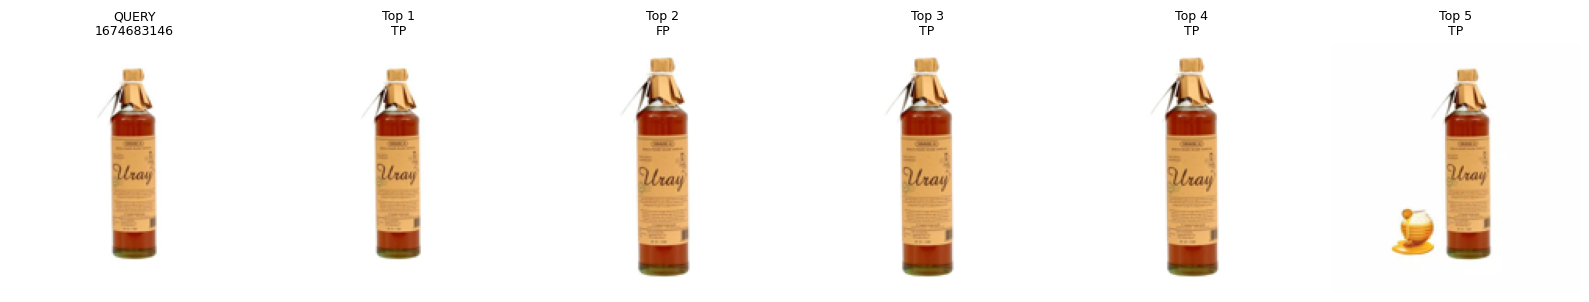

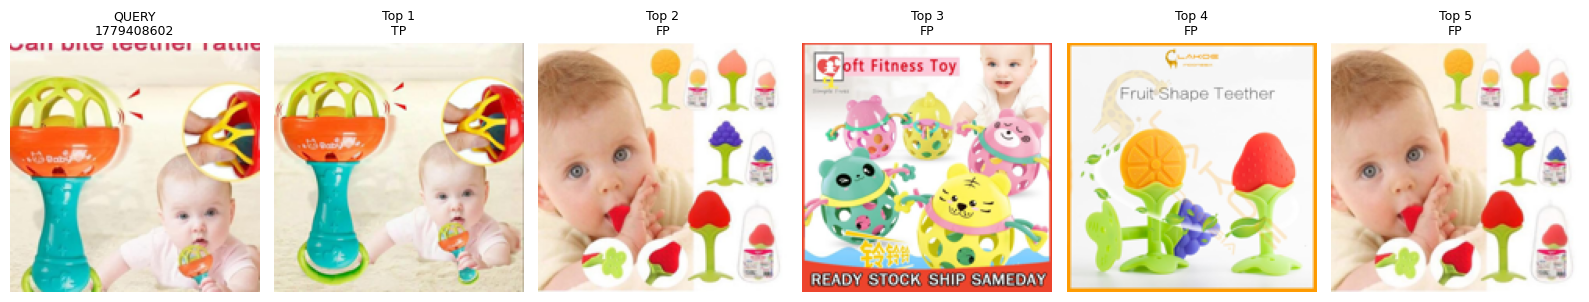

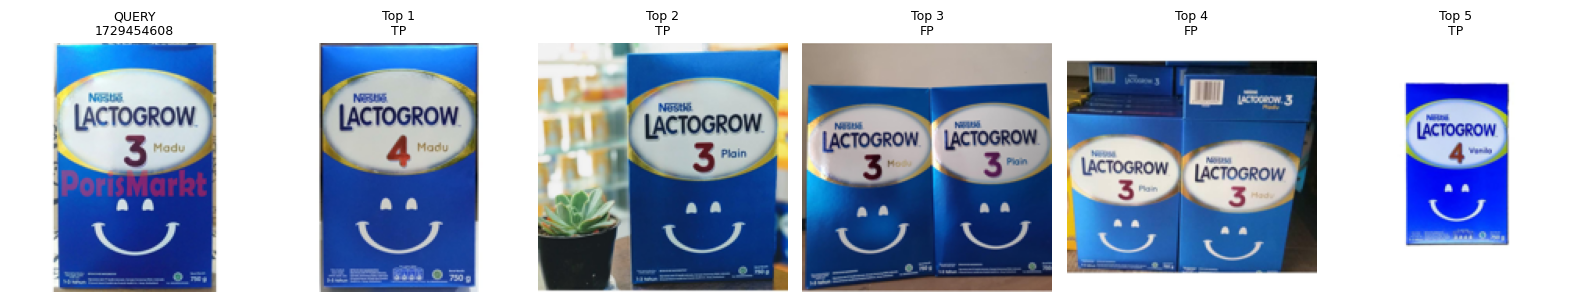

View ảnh crop:


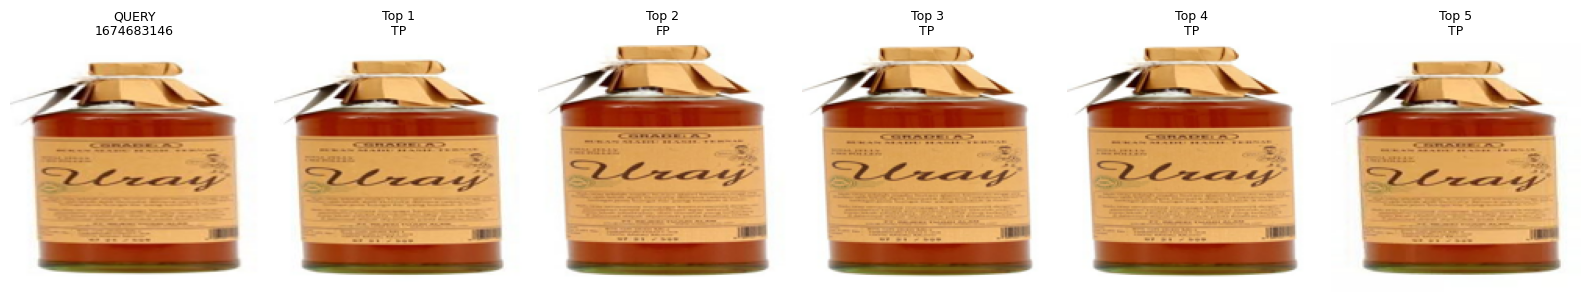

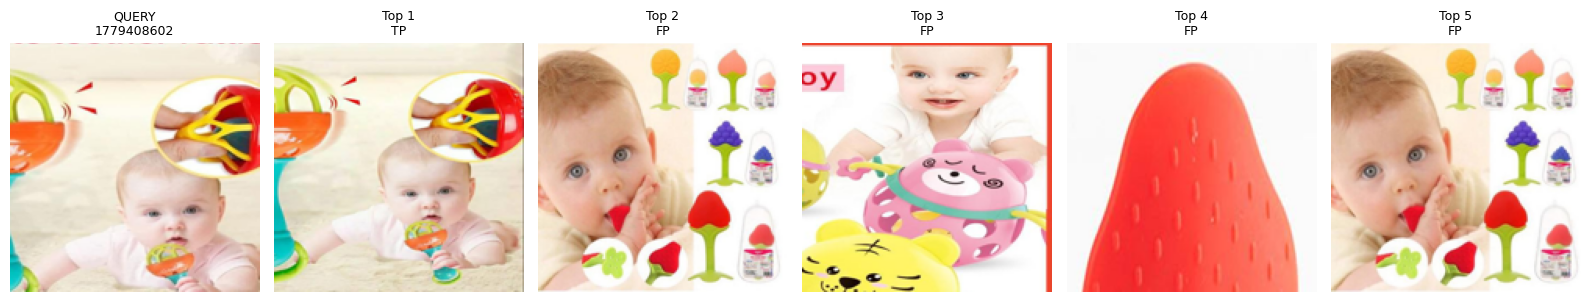

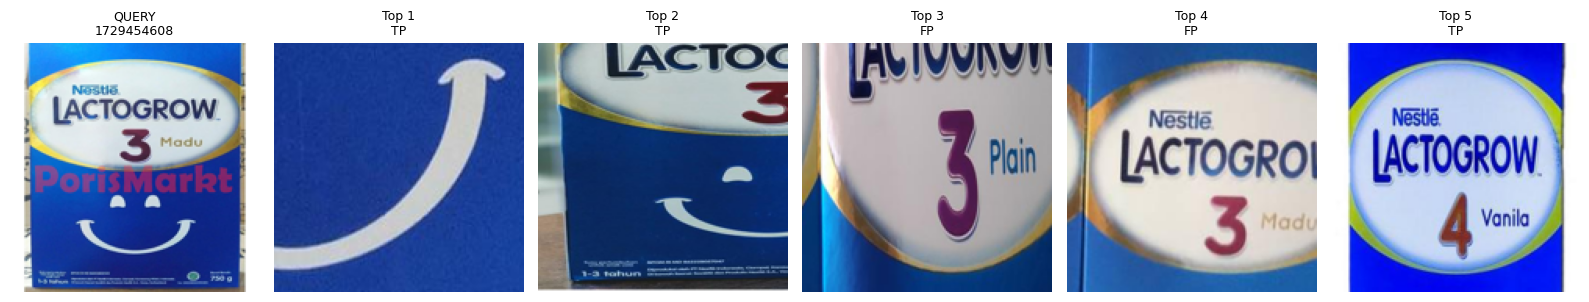

In [29]:
import matplotlib.pyplot as plt


def load_show_image(path, size=(160, 160), crop_row=None):
    img = load_image_safe(path)
    if crop_row is not None:
        img = crop_with_padding(img, crop_row)
    return img.resize(size)


def visualize_query(q_idx, use_crop_view=False):
    top = best_top_indices[q_idx][:5]
    q_label = labels[q_idx]

    fig, axes = plt.subplots(1, 6, figsize=(16, 3))

    q_img = load_show_image(
        candidate_df.loc[q_idx, 'image_path'],
        crop_row=crop_box_df.iloc[q_idx] if use_crop_view else None
    )
    axes[0].imshow(q_img)
    axes[0].set_title('QUERY\n' + str(q_label), fontsize=9)
    axes[0].axis('off')

    for rank, idx in enumerate(top, start=1):
        img = load_show_image(
            candidate_df.loc[idx, 'image_path'],
            crop_row=crop_box_df.iloc[idx] if use_crop_view else None
        )
        axes[rank].imshow(img)
        ok = labels[idx] == q_label
        axes[rank].set_title(f'Top {rank}\n' + ('TP' if ok else 'FP'), fontsize=9)
        axes[rank].axis('off')

    plt.tight_layout()
    plt.show()

sample_indices = np.random.default_rng(SEED).choice(len(candidate_df), size=min(3, len(candidate_df)), replace=False)
print('View ảnh gốc:')
for q in sample_indices:
    visualize_query(int(q), use_crop_view=False)

print('View ảnh crop:')
for q in sample_indices:
    visualize_query(int(q), use_crop_view=True)

## CELL 17 - Nhận xét mẫu đưa vào báo cáo

```text
Trong tuần này, nhóm cải tiến phương pháp truy xuất ảnh bằng cách bổ sung nhánh crop vùng sản phẩm trước khi trích xuất đặc trưng ảnh. Cụ thể, YOLO/SAHI được dùng để xác định vùng sản phẩm chính trong ảnh, sau đó ảnh crop được đưa qua cùng backbone DINOv2/ResNet để lấy đặc trưng bổ sung. Điểm tương đồng cuối cùng được tính bằng score-level fusion giữa đặc trưng ảnh gốc, đặc trưng ảnh crop, đặc trưng văn bản TF-IDF từ tiêu đề sản phẩm và pHash boost cho các ảnh gần trùng.

Cách làm này giữ đúng bản chất bài toán Visual Search của Shopee, vì đầu ra vẫn là Top-K ảnh sản phẩm tương đồng theo label_group, không chuyển sai hướng sang object detection thuần túy. YOLO/SAHI chỉ đóng vai trò tiền xử lý để giảm nhiễu nền và giúp đặc trưng ảnh tập trung hơn vào vùng sản phẩm.

Notebook tự chạy nhiều cấu hình trọng số fusion và chọn cấu hình có mAP@5 cao nhất. Kết quả được lưu trong các file STRONG_best_fusion_summary.csv, STRONG_all_fusion_configs_summary.csv và REPORT_strong_fusion_comparison_table.xlsx để đưa vào báo cáo.
```